<a href="https://colab.research.google.com/github/Essieng/Data-Analysis-with-Open-Source/blob/practice/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_14%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 14강 비정형 데이터 분석 : 패션 사진 데이터 활용

### 목표

- 비정형 데이터를 인공지능 모델로 분석하여 실무에서 활용 가능한 보고서 형태로 가공

- 패션 트렌드라는 구체적인 주제를 통해, 비정형 데이터 분석의 실질적인 활용 방안을 경험하고자 함


### 분석 프로세스 개요

1. 데이터 수집
  - requests를 이용한 RSS 데이터 수집
  - lxml을 이용한 XML 파싱
  - 이미지 데이터 추출
2. VLM을 이용한 이미지 분석
  - 프롬프트를 이용한 이미지 필터링
  - 프롬프트를 이용한 스타일 분석
3. LLM을 이용한 키워드 분석 및 보고서 작성
  - 텍스트 전처리
  - 색상 및 스타일 키워드 추출
  - 워드 클라우드 분석
  - 보고서 작성

# 주의 : 런타임 GPU 로 설정 필요

In [ ]:
# 4bit VLM 처리를 위한 bitsandbytes 설치
# LLM 처리를 위한 VLLM 설치 (오래걸리는 작업(>5분)이므로 미리 실행!)
!pip install bitsandbytes==0.45.3 vllm==0.7.3 transformers==4.48.2
# 필요 시 세션 재시작

In [ ]:
# 한글 처리를 위한 matplotlib 설정 (1)

!sudo apt-get install -y fonts-nanum
!sudo fc-cache –fv
!rm ~/.cache/matplotlib -rf

- 런타임 -> 세션 다시 시작

In [1]:
# 한글 처리를 위한 matplotlib 설정 (2)

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

# 1. 데이터 수집 및 전처리

## 14-1 RSS 피드에서 이미지 URL 추출

In [ ]:
import requests
from lxml import etree
from lxml.html import fromstring
import pandas as pd

def extract_unique_images(rss_url):
    ## 주어진 RSS 피드 URL에서 고유한 이미지 URL들을 추출하는 함수 정의
    try:
        ## requests 라이브러리를 사용하여 RSS 피드 URL로부터 내용을 가져옴
        response = requests.get(rss_url)
        ## 가져온 XML 응답 내용을 lxml의 etree.fromstring으로 파싱하여 XML 트리 root를 생성
        root = etree.fromstring(response.content)

        image_urls = set()

        ## XML 트리에서 모든 'item' 태그를 XPath를 사용하여 순회
        for item in root.xpath('//item'):
            description = item.find('description')
            if description is not None and description.text:
                ## description의 텍스트 내용을 lxml.html.fromstring으로 파싱하여 HTML 트리를 생성
                html_tree = fromstring(description.text)
                ## HTML 트리에서 첫 번째 <img> 태그의 'src' 속성 값을 XPath를 사용하여 추출
                img_url = html_tree.xpath('string(//img/@src)')
                if img_url:
                    image_urls.add(img_url)

        return list(image_urls)

    except Exception as e:
        ## 오류 발생 시 오류 메시지를 출력하고 빈 리스트를 반환
        print(f"Error occurred: {e}")
        return []

rss_url = "https://glltn.com/feed/"
## extract_unique_images 함수를 호출하여 고유한 이미지 URL들을 추출
unique_images = extract_unique_images(rss_url)

## 추출된 이미지 URL 리스트를 사용하여 'image'라는 열을 가진 pandas DataFrame을 생성
df = pd.DataFrame(unique_images, columns=["image"])

## 14-2 수집 데이터 확인

In [4]:
from IPython.display import display, HTML

def path_to_image_html(path):
    ## 이미지 경로를 HTML img 태그로 변환하는 함수
    return f'<img src="{path}" width="300" />'

## DataFrame의 스타일을 설정하여 이미지 너비를 300px로 지정
df.style.set_table_styles([{'selector': 'img', 'props': 'width: 300px;'}])

## DataFrame을 HTML로 변환하여 출력. 이미지 열은 path_to_image_html 함수로 포맷팅
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image
0,
1,
2,
3,
4,
5,
6,
7,
8,
9,


## 2. VLM을 이용한 이미지 분석

## 14-3 VLM 모델 로드

In [ ]:
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer

## 'openbmb/MiniCPM-V-2_6-int4' 모델을 사전 훈련된 가중치와 함께 로드
## trust_remote_code=True는 허브에서 사용자 정의 코드를 실행할 수 있도록 허용
model = AutoModel.from_pretrained('openbmb/MiniCPM-V-2_6-int4', trust_remote_code=True)
## 로드된 모델에 해당하는 토크나이저를 로드
tokenizer = AutoTokenizer.from_pretrained('openbmb/MiniCPM-V-2_6-int4', trust_remote_code=True)
## 모델을 평가 모드로 설정 (드롭아웃 등 훈련 시에만 필요한 기능 비활성화)
model.eval()

![](https://farm3.staticflickr.com/2677/4434956914_6e95a22940_z.jpg)

## 14-4 이미지 질문 응답 예시

In [6]:
from transformers import set_seed

## 재현성을 위해 시드(seed)를 42로 설정
set_seed(42)
## 예시 이미지 URL 정의
image_url = 'https://farm3.staticflickr.com/2677/4434956914_6e95a22940_z.jpg'
## requests로 이미지 다운로드 후 PIL Image 객체로 열고 RGB 형식으로 변환
image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')
## 이미지에 대한 질문 정의
question = 'how many cats in the photo?'
## 모델 입력 형식에 맞춰 메시지 구성 (이미지와 질문 포함)
msgs = [{'role': 'user', 'content': [image, question]}]
## 모델의 chat 함수를 호출하여 이미지와 질문에 대한 응답 생성
result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
## 모델의 응답 출력
print(result)

preprocessor_config.json:   0%|          | 0.00/714 [00:00<?, ?B/s]

processing_minicpmv.py: 0.00B [00:00, ?B/s]

image_processing_minicpmv.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- image_processing_minicpmv.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- processing_minicpmv.py
- image_processing_minicpmv.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:590: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=

1


In [7]:
set_seed(42)
## 이미지에 대한 질문을 업데이트. 책 표지의 고양이도 포함하도록 요청
question = 'how many cats in the photo? including the books cover.'
## 모델 입력 형식에 맞춰 메시지 구성 (이전에 로드된 이미지와 업데이트된 질문 포함)
msgs = [{'role': 'user', 'content': [image, question]}]
## 모델의 chat 함수를 호출하여 업데이트된 질문에 대한 응답 생성
result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
## 모델의 응답 출력
print(result)

1


In [8]:
set_seed(42)
## 이미지에 대한 질문을 'describe the photo'로 설정하여 이미지 내용을 설명하도록 요청
question = 'describe the photo'
## 모델 입력 형식에 맞춰 메시지 구성 (이전에 로드된 이미지와 설명 요청 질문 포함)
msgs = [{'role': 'user', 'content': [image, question]}]
## 모델의 chat 함수를 호출하여 이미지에 대한 설명을 생성
result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
## 모델의 응답 (이미지 설명) 출력
print(result)

The photo shows a book with the title "why dogs are better than cats" and an image of a cat sitting on top of a dog's head. The book is placed on a flat surface, and next to it stands a real cat that appears to be looking at the book cover with some curiosity or disapproval.


## 14-5 의류 이미지 여부 판단

In [9]:
def is_picture_of_clothing(image_url):
    ## 이미지 URL이 의류 사진인지 판단하는 함수
    # 의류가 포함된 사진인지 확인하는 질문 작성 (영어로)
    question = 'Is this a picture of clothing? MUST say yes or no.'
    image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')
    msgs = [{'role': 'user', 'content': [image, question]}]
    result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer, temperature=0.1)
    print(result)
    ## 응답에 'yes'가 포함되어 있는지 확인하여 True/False 반환
    return 'yes' in result.lower()

## DataFrame의 'image' 열에 함수를 적용하여 'is_clothing' 열에 결과 저장
df['is_clothing'] = df['image'].apply(is_picture_of_clothing)

No, the image does not appear to be of clothing. It is an artistic representation that seems to focus on a close-up of a face or part of a face, with a stylized and abstract approach rather than depicting any wearable items.
No, the image is not of clothing. It is a photograph of a book cover featuring a man and a car with an American flag. The content suggests that it is related to photography, specifically the work of Joel Meyerowitz over a span of several decades.
Yes, this image is of clothing. The focus is on the knitwear worn by the individual, which includes a beanie and a sweater. These items are clearly visible and are the main subjects of the photograph, indicating that the picture is indeed showcasing clothing.
Yes, this image is of clothing. It appears to be a fashion photograph showcasing the individual's attire, which includes a black blazer and tie-dye trousers. The focus on the outfit suggests that it may be used for promotional or retail purposes, highlighting the styl

## 14-6 의류 판단 결과 시각화

In [10]:
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image,is_clothing
0,,False
1,,False
2,,True
3,,True
4,,True
5,,True
6,,True
7,,True
8,,True
9,,True


## 14-7 의류 이미지 필터링

In [15]:
## 'is_clothing' 열의 값이 True인 행들만 필터링하여 DataFrame을 업데이트
df = df[df['is_clothing']]
df

,image,is_clothing,style
2,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes in the image suggests...
3,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes can be characterized ...
4,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes in the image leans to...
5,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes in this image suggest...
6,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes in this image is indi...
7,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes in the image leans to...
8,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes worn by the individua...
9,https://glltn.com/wp-content/blogs.dir/1/files...,True,The clothing style in the image suggests a ble...
10,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes in the image suggests...
11,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothes in the image reflects...


## 14-8 의류 스타일 분석

In [14]:
def describe_style(image_url):
    ## 주어진 이미지 URL의 의류 스타일을 분석하는 함수
    question = 'Analyze the style of the clothes. Please let me explain the colors and trend changes.'
    image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')
    msgs = [{'role': 'user', 'content': [image, question]}]
    ## 모델의 chat 함수를 호출하여 이미지에 대한 스타일 분석 응답 생성
    result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
    return result

## 필터링된 DataFrame의 'image' 열에 describe_style 함수를 적용
## 결과는 'style'이라는 새로운 열에 저장
df['style'] = df['image'].apply(describe_style)

/tmp/ipython-input-1874085826.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['style'] = df['image'].apply(describe_style)


In [16]:
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image,is_clothing,style
2,,True,"The style of the clothes in the image suggests a preference for comfort and warmth, which are key aspects of casual winter wear. The grey knit sweater is a classic choice that has been popular for many seasons due to its versatility and ability to keep the wearer warm without sacrificing style. The high-neck design adds an element of coziness and can also be practical for keeping the neck warm.\n\nThe hat, with its dark color and contrasting light stripes, follows a trend that often includes functional headwear with subtle patterns or accents. Such hats not only provide warmth but also add a stylish touch to the overall look. The combination of the sweater and hat indicates a practical approach to fashion, focusing on functionality as well as aesthetics during colder weather.\n\nOverall, the clothing choices reflect a contemporary casual style that emphasizes both comfort and a sense of understated elegance through the use of neutral colors and simple yet effective design elements."
3,,True,"The style of the clothes can be characterized as a blend of classic and contemporary fashion trends. The black blazer with its structured shoulders and high collar is reminiscent of timeless tailoring, often associated with formal or business attire. However, the presence of a white turtleneck underneath adds a modern twist to this look, suggesting a fusion of casual and smart-casual elements.\n\nThe tie-dye pattern on the pants introduces a bold and unconventional element to the outfit. Tie-dye has been a recurring trend in various forms over the years, but its resurgence in popularity often coincides with shifts towards more expressive and individualistic styles. This choice of pattern indicates a willingness to stand out and embrace vibrant, eye-catching prints.\n\nOverall, the combination of classic cut garments with a playful, colorful bottom creates a balanced yet distinctive ensemble that reflects both traditional and current fashion sensibilities."
4,,True,"The style of the clothes in the image leans towards a minimalist and functional design, which is often associated with modern urban fashion. The olive green color of the coats suggests a preference for earthy tones that are versatile and can be easily paired with various outfits. This choice of color also indicates a trend towards natural and subdued hues that provide a calm and sophisticated look.\n\nThe oversized fit of the coats reflects a contemporary fashion trend where comfort and ease of movement are prioritized over traditional tailoring. Such designs are popular for their relaxed silhouette, which allows for layering and adaptability to different body types. The presence of hoods on both coats adds to the practicality, offering protection against weather elements while maintaining a casual aesthetic.\n\nUnderneath the outerwear, the use of grey sweaters and turtlenecks points to a layering technique that has been widely embraced in recent years. Layering not only provides warmth but also offers a way to create depth and interest in an outfit without adding bulk. The choice of neutral colors like grey further emphasizes the understated elegance and timeless quality of the ensemble.\n\nOverall, the clothing style captured in the image aligns with current fashion trends that favor functionality, comfort, and a palette of muted, natural colors."
5,,True,"The style of the clothes in this image suggests a contemporary casual fashion with an emphasis on comfort and individuality. The dark grey jacket is tailored but not overly formal, which aligns with modern trends that favor versatile pieces that can be dressed up or down. The fabric appears to have a textured finish, adding depth and interest to the garment without being ostentatious.\n\nThe long hair and beard are indicative of a relaxed and possibly bohemian aesthetic, which has been popular in various forms over the years but saw a resurgence in popularity during certain periods such as 

# 3. LLM을 이용한 키워드 분석 및 보고서 작성

## 14-9 언어 모델(LLM) 로드

In [ ]:
from vllm import LLM, SamplingParams

## vLLM 라이브러리를 사용하여 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct' 모델을 로드
## gpu_memory_utilization은 GPU 메모리 사용 비율을 0.5로 설정
## max_model_len은 모델이 처리할 수 있는 최대 토큰 길이를 10000으로 설정
llm = LLM(model= 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', gpu_memory_utilization= 0.5, max_model_len= 10000)

## 14-10 색상 정보 추출

In [17]:
from vllm import SamplingParams ## SamplingParams 임포트가 필요

def extract_color(style):
  ## 주어진 스타일 설명 텍스트에서 색상을 한글로 추출하는 함수
  prompt = [
      {
          "role": "system",
          "content": "You are EXAONE model from LG AI Research, a helpful assistant."
      },
      {
          "role": "user",
          "content": f"다음의 글에서 색상을 한글로 추출해주세요. 색상 외에 다른 정보는 적지 말아주세요.\n{style}" # vlm이 작성한 글에서 색상 정보 추출, 한글로 번역하면서
      }
  ]
  ## 샘플링 파라미터 설정 (온도, top_p, 최대 토큰 수)
  sampling_params = SamplingParams(temperature=0.2, top_p=0.95, max_tokens=1024)
  ## LLM 모델을 사용하여 프롬프트에 대한 응답 생성
  result = llm.chat(prompt, sampling_params)[0].outputs[0].text
  print(result)
  return result

## DataFrame의 'style' 열에 extract_color 함수를 적용
## 결과는 'color'라는 새로운 열에 저장
df['color'] = df['style'].apply(extract_color)

INFO 09-30 08:19:55 chat_utils.py:332] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s, est. speed input: 754.56 toks/s, output: 24.74 toks/s]


**색상:**
- 회색


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s, est. speed input: 259.32 toks/s, output: 39.65 toks/s]


- **검정색** (Black)
- **흰색** (White)
- **파란색** (Blue, implied by tie-dye patterns often featuring blue tones)


...

- ** stripes**
- **denim**


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.76it/s, est. speed input: 500.60 toks/s, output: 35.38 toks/s]


- 녹색 (Green)
- 검정색 또는 갈색 (Dark Burgundy or Maroon)


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.95it/s, est. speed input: 712.44 toks/s, output: 14.97 toks/s]

색상: 검정색


## 14-11 스타일 키워드 추출

In [18]:
from vllm import SamplingParams ## SamplingParams 임포트가 필요

def extract_color(style):
  ## 주어진 스타일 설명 텍스트에서 스타일 키워드를 한글로 추출하는 함수
  prompt = [
      {
          "role": "system",
          "content": "You are EXAONE model from LG AI Research, a helpful assistant."
      },
      {
          "role": "user",
          "content": f"다음의 글에서 스타일 키워드를 한글로 추출해주세요. 스타일 키워드 외에 다른 정보는 적지 말아주세요.\n{style}" # vlm이 작성한 글에서 스타일 키워드 추출, 한글로 번역하면서
      }
  ]
  ## 샘플링 파라미터 설정 (온도, top_p, 최대 토큰 수)
  sampling_params = SamplingParams(temperature=0.2, top_p=0.95, max_tokens=1024)
  ## LLM 모델을 사용하여 프롬프트에 대한 응답 생성
  result = llm.chat(prompt, sampling_params)[0].outputs[0].text
  print(result)
  return result

## DataFrame의 'style' 열에 extract_color 함수를 적용 (함수 이름은 이전과 동일하지만 기능 변경)
## 결과는 'keyword'라는 새로운 열에 저장
df['keyword'] = df['style'].apply(extract_color)

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it, est. speed input: 209.32 toks/s, output: 39.14 toks/s]


- 편안함
- 따뜻함
- 캐주얼
- 겨울용
- 클래식
- 유연성
- 보온성
- coziness
- 실용성
- 기능성
- 단순함
- 세련됨


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it, est. speed input: 137.70 toks/s, output: 41.20 toks/s]


- **클래식**
- **현대적**
- **구조적**
- **높은**
- **모던**
- **퓨전**
- **볼드**
- **비정통적**
- **표현적**
- **개별적**
- **균형**
- **독창적**


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it, est. speed input: 262.71 toks/s, output: 38.73 toks/s]


...

- 캐주얼
- 스트리트웨어
- 스트라이프 패턴
- nautical/해변풍
- 데님 소재
- 버킷햇
- 레이어드 스타일
- 실용성
- 트렌디함


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.17s/it, est. speed input: 244.63 toks/s, output: 38.63 toks/s]


- 전통적
- 현대적
- 버튼업
- 클래식
- 긴 소매
- 깊이감
- 대조
- 현대 캐주얼
- 패턴
- 빈티지 스타일
- 텍스처 혼합
- 클래식 아이템


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it, est. speed input: 192.95 toks/s, output: 40.20 toks/s]

- 미니멀리즘
- 현대적
- 클래식 블랙
- 심플함
- 우아함
- 다양성
- 캐주얼하면서도 세련됨
- 편안함
- 기능성
- 언더stated elegance
- timeless style


In [19]:
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image,is_clothing,style,color,keyword
2,,True,"The style of the clothes in the image suggests a preference for comfort and warmth, which are key aspects of casual winter wear. The grey knit sweater is a classic choice that has been popular for many seasons due to its versatility and ability to keep the wearer warm without sacrificing style. The high-neck design adds an element of coziness and can also be practical for keeping the neck warm.\n\nThe hat, with its dark color and contrasting light stripes, follows a trend that often includes functional headwear with subtle patterns or accents. Such hats not only provide warmth but also add a stylish touch to the overall look. The combination of the sweater and hat indicates a practical approach to fashion, focusing on functionality as well as aesthetics during colder weather.\n\nOverall, the clothing choices reflect a contemporary casual style that emphasizes both comfort and a sense of understated elegance through the use of neutral colors and simple yet effective design elements.",**색상:**\n- 회색,- 편안함\n- 따뜻함\n- 캐주얼\n- 겨울용\n- 클래식\n- 유연성\n- 보온성\n- coziness\n- 실용성\n- 기능성\n- 단순함\n- 세련됨
3,,True,"The style of the clothes can be characterized as a blend of classic and contemporary fashion trends. The black blazer with its structured shoulders and high collar is reminiscent of timeless tailoring, often associated with formal or business attire. However, the presence of a white turtleneck underneath adds a modern twist to this look, suggesting a fusion of casual and smart-casual elements.\n\nThe tie-dye pattern on the pants introduces a bold and unconventional element to the outfit. Tie-dye has been a recurring trend in various forms over the years, but its resurgence in popularity often coincides with shifts towards more expressive and individualistic styles. This choice of pattern indicates a willingness to stand out and embrace vibrant, eye-catching prints.\n\nOverall, the combination of classic cut garments with a playful, colorful bottom creates a balanced yet distinctive ensemble that reflects both traditional and current fashion sensibilities.","- **검정색** (Black)\n- **흰색** (White)\n- **파란색** (Blue, implied by tie-dye patterns often featuring blue tones)",- **클래식**\n- **현대적**\n- **구조적**\n- **높은**\n- **모던**\n- **퓨전**\n- **볼드**\n- **비정통적**\n- **표현적**\n- **개별적**\n- **균형**\n- **독창적**
4,,True,"The style of the clothes in the image leans towards a minimalist and functional design, which is often associated with modern urban fashion. The olive green color of the coats suggests a preference for earthy tones that are versatile and can be easily paired with various outfits. This choice of color also indicates a trend towards natural and subdued hues that provide a calm and sophisticated look.\n\nThe oversized fit of the coats reflects a contemporary fashion trend where comfort and ease of movement are prioritized over traditional tailoring. Such designs are popular for their relaxed silhouette, which allows for layering and adaptability to different body types. The presence of hoods on both coats adds to the practicality, offering protection against weather elements while maintaining a casual aesthetic.\n\nUnderneath the outerwear, the use of grey sweaters and turtlenecks points to a layering technique that has been widely embraced in recent years. Layering not only provides warmth but also offers a way to create depth and interest in an outfit without adding bulk. The choice of neutral colors like grey further emphasizes the understated elegance and timeless quality of the ensemble.\n\nOverall, the clothing style captured in the image aligns with current fashion trends that favor functionality, comfort, and a palette of muted, natural colors.",- 올리브 그린 (Olive Green),- 미니멀리즘\n- 기능성\n- 현대 도시 패션\n- earthy tones\n- 자연스러운 색상\n- 편안함\n- 유연한 실루엣\n- 실용성\n- 레이어드 스타일\n- 중성적 색상
5,,True,"The style of the clothes in this image suggests a contemporary casual fashion with an emphasis on comfort and individ

## 14-12 텍스트 데이터 정제

In [20]:
import re

def clean_text(text):
    ## 텍스트에서 특수 문자 및 HTML 태그를 제거하고 소문자로 변환하는 함수
    if isinstance(text, str):
       ## 영문, 숫자, 한글, 공백을 제외한 모든 문자 제거
       text = re.sub(r'[^a-zA-Z0-9가-힣\s]', '', text)
       ## HTML 태그 제거
       text = re.sub(r'<[^>]*>', '', text)
       ## 텍스트를 소문자로 변환
       text = text.lower()
       return text
    else:
        return ""

## 'color' 열의 텍스트 데이터 정제
df['color'] = df['color'].apply(clean_text)
## 'keyword' 열의 텍스트 데이터 정제
df['keyword'] = df['keyword'].apply(clean_text)

## 14-13 워드 클라우드 생성 및 시각화

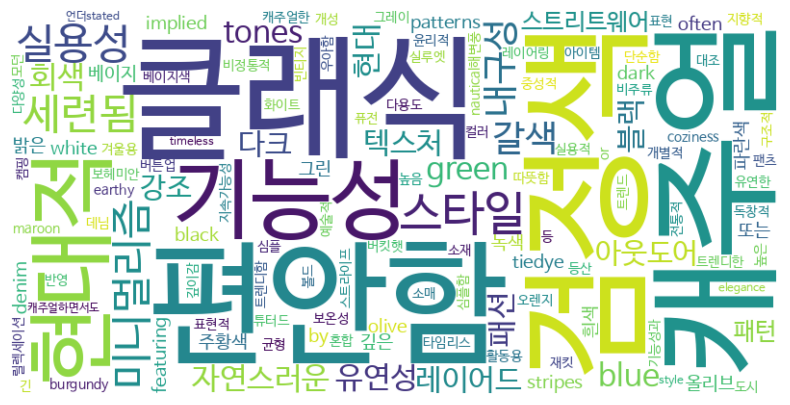

In [21]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_word_count(df):
    ## DataFrame의 'color'와 'keyword' 열에서 단어 빈도를 계산하는 함수
    if not df.empty:
        ## 'color' 열의 모든 단어를 리스트로 합침
        all_nouns = df['color'].apply(str.split).sum()
        ## 'keyword' 열의 모든 단어를 추가
        all_nouns += df['keyword'].apply(str.split).sum()
        ## '색상' 단어를 제외한 모든 단어를 필터링
        all_nouns = [word for word in all_nouns if word not in ['색상']]
        ## 단어 빈도를 Counter 객체로 반환
        return Counter(all_nouns)
    return Counter() ## DataFrame이 비어있으면 빈 Counter 반환

def create_wordcloud(word_count):
    ## 단어 빈도수를 기반으로 워드 클라우드를 생성하고 시각화하는 함수
    if not word_count: ## 단어 빈도가 없으면 워드클라우드 생성하지 않음
        print("No words to generate word cloud.")
        return

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' ## 한글 폰트 경로 지정
        ).generate_from_frequencies(word_count)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off") ## 축 표시 제거
    plt.show() ## 워드 클라우드 출력

## DataFrame에서 단어 빈도 계산
word_count = get_word_count(df)
## 계산된 단어 빈도로 워드 클라우드 생성 및 시각화
create_wordcloud(word_count)

## 14-14 트렌드 분석 보고서 생성 프롬프트 구성 및 실행

## 14-15 분석 보고서 시각화

In [22]:
from vllm import SamplingParams ## SamplingParams 임포트가 필요

## 시스템 메시지로 시작하는 프롬프트 리스트 초기화
prompt = [
    {
        "role": "system",
        "content": "You are EXAONE model from LG AI Research, a helpful assistant."
    }
]
## DataFrame의 각 행을 순회하며 '스타일 노트'와 '이미지 URL'을 사용자 메시지로 추가
for row in df.itertuples():
  prompt.append({"role": "user", "content": f"스타일 노트: {row.style}\n이미지 url:{row.image}"})
## 마지막으로, 종합적인 트렌드 분석 보고서 작성을 요청하는 사용자 메시지 추가
## 보고서 제목, 내용의 전문성, 마크다운 형식, 예시 이미지 포함을 지시
prompt.append({"role": "user", "content": "주어진 스타일 노트를 토대로 종합적인 트렌드 방향의 분석 보고서를 작성해주세요. 보고서의 제목은 해외 룩북 스타일 분석입니다. 내용은 전문적이면서 명확하게 작성해주세요. 문서 형식은 마크다운 입니다. 예시 이미지를 적절한 곳에 추가해서 바로 볼 수 있도록 해주세요."})

## 샘플링 파라미터 설정 (온도, top_p, 최대 토큰 수)
sampling_params = SamplingParams(temperature=0.2, top_p=0.95, max_tokens=4096)
## LLM 모델을 사용하여 구성된 프롬프트에 대한 응답 생성
result = llm.chat(prompt, sampling_params)[0].outputs[0].text

Processed prompts: 100%|██████████| 1/1 [00:42<00:00, 42.03s/it, est. speed input: 71.73 toks/s, output: 38.37 toks/s]


In [23]:
from IPython.display import display, Markdown

## LLM으로부터 생성된 결과(Markdown 형식의 보고서)를 Jupyter 환경에 표시
display(Markdown(result))

# 해외 룩북 스타일 분석 보고서

## 개요
본 보고서는 최근 여러 패션 룩북에서 관찰되는 주요 트렌드를 종합적으로 분석하고, 이를 통해 미래 패션 경향성을 예측하는 데 초점을 맞춥니다. 다양한 이미지와 함께 각 트렌드의 특징과 그 배경을 상세히 살펴봅니다.

## 트렌드 분석

### 1. **편안함과 기능성의 융합**
- **예시 이미지**: [https://glltn.com/wp-content/blogs.dir/1/files/2025/09/tone-fall-winter-2025-collection-lookbook-08-1024x683.jpg](https://glltn.com/wp-content/blogs.dir/1/files/2025/09/tone-fall-winter-2025-collection-lookbook-08-1024x683.jpg)
  - **특징**: 겨울철 캐주얼 웨어에서 편안함과 보온성을 중시하는 경향이 두드러집니다. 예를 들어, **회색 니트 스웨터**와 **고온한 넥 디자인**은 보온성과 함께 스타일리시함을 제공합니다.
  - **트렌드**: 기능성과 스타일의 균형을 추구하며, 다양한 활동에 적합한 의류 선택이 중요합니다.

### 2. **클래식과 현대의 융합**
- **예시 이미지**: [https://glltn.com/wp-content/blogs.dir/1/files/2025/09/bluebluejapan-fall-winter-2025-collection-lookbook-11-1024x683.jpg](https://glltn.com/wp-content/blogs.dir/1/files/2025/09/bluebluejapan-fall-winter-2025-collection-lookbook-11-1024x683.jpg)
  - **특징**: **블랙 블레이저**와 **화이트 터틀넥**의 조합은 클래식한 테일러링과 현대적인 캐주얼 요소를 결합한 사례입니다. **tie-dye 패턴**은 개성 표현의 수단으로 활용됩니다.
  - **트렌드**: 전통적인 디자인 요소와 현대적인 패턴 및 색상의 융합으로 개성과 실용성을 동시에 추구합니다.

### 3. **실용성과 미니멀리즘**
- **예시 이미지**: [https://glltn.com/wp-content/blogs.dir/1/files/2025/09/minotaur-fall-winter-2025-collection-lookbook-38-1024x683.jpg](https://glltn.com/wp-content/blogs.dir/1/files/2025/09/minotaur-fall-winter-2025-collection-lookbook-38-1024x683.jpg)
  - **특징**: **올리브 그린 코트**와 **오versized 핏**은 실용성과 편안함을 강조합니다. **금속 Eyelets**가 있는 신발은 기능성과 스타일을 동시에 제공합니다.
  - **트렌드**: 기능적인 디자인과 간결한 실루엣이 결합되어 일상 생활과 활동에 적합한 의류가 선호됩니다.

### 4. **실용적이고 개성적인 캐주얼 스타일**
- **예시 이미지**: [https://glltn.com/wp-content/blogs.dir/1/files/2025/09/south2-west8-suicoke-fall-winter-2025-beetle-lo-01-1024x683.jpg](https://glltn.com/wp-content/blogs.dir/1/files/2025/09/south2-west8-suicoke-fall-winter-2025-beetle-lo-01-1024x683.jpg)
  - **특징**: **어두운 회색 재킷**과 **밝은 오렌지 코트**의 조합은 실용성과 개성 표현을 동시에 추구합니다. **다크 컬러**와 **기능적인 헤드웨어**는 편안함과 스타일을 균형 있게 제공합니다.
  - **트렌드**: 실용적인 디자인 요소와 개성적인 색상 및 패턴의 조화로 개인의 스타일을 강조합니다.

### 5. **미니멀리즘과 지속 가능성**
- **예시 이미지**: [https://glltn.com/wp-content/blogs.dir/1/files/2025/09/takesons-fall-winter-2025-collection-lookbook-11-1024x683.jpg](https://glltn.com/wp-content/blogs.dir/1/files/2025/09/takesons-fall-winter-2025-collection-lookbook-11-1024x683.jpg)
  - **특징**: **어두운 색상**과 **단순한 디자인**은 미니멀리즘 트렌드를 반영합니다. **다크 그레이 재킷**과 **화이트 셔츠**의 조합은 편안함과 고급스러움을 동시에 제공합니다.
  - **트렌드**: 지속 가능한 소재와 디자인을 활용한 의류가 중요하며, 품질과 기능성을 중시하는 경향이 있습니다.

### 6. **실용적이고 트렌디한 스트리트웨어**
- **예시 이미지**: [https://glltn.com/wp-content/blogs.dir/1/files/2025/09/gypsy-sons-fall-winter-2025-collection-lookbook-14-1024x683.jpg](https://glltn.com/wp-content/blogs.dir/1/files/2025/09/gypsy-sons-fall-winter-2025-collection-lookbook-14-1024x683.jpg)
  - **특징**: **블랙 재킷**과 **화이트 셔츠**의 조합은 스트리트웨어의 기본적인 요소를 보여줍니다. **보헤미안 스타일**의 헤어스타일과 **다크 컬러**는 개성 표현의 수단입니다.
  - **트렌드**: 실용성과 트렌디한 요소의 결합으로 개인의 스타일을 강조하며, 다양한 활동에 적합한 의류 선택이 중요합니다.

### 결론
최근 패션 트렌드는 편안함과 기능성을 중시하면서도 개인의 스타일과 개성 표현을 중요시하는 방향으로 진화하고 있습니다. 미니멀리즘과 지속 가능성에 대한 관심이 증가하면서, 클래식한 디자인 요소와 현대적인 패턴의 융합이 주목받고 있습니다. 이러한 경향은 다양한 활동과 계절에 걸쳐 유연하게 적용될 수 있는 실용적이고 개성적인 의류 스타일을 선호하는 소비자들의 요구를 반영하고 있습니다.